# AI-Driven Fraud Detection :- Experiments Runs all six models (Logistic Regression, Random Forest, XGBoost, MLP, Isolation Forest, Autoencoder)on the Kaggle Credit Card Fraud Detection dataset

## 1. Install dependencies

In [ ]:
!pip install xgboost shap imbalanced-learn -q

## 2. Upload the dataset

In [ ]:
from google.colab import filesuploaded = files.upload()

In [ ]:
from google.colab import files
uploaded = files.upload()  # select creditcard.csv in the file picker
DATA_PATH = list(uploaded.keys())[0]
print("Using file:", DATA_PATH)

Saving creditcard.csv to creditcard (1).csv
Using file: creditcard (1).csv


In [ ]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

*(Alternative: mount Google Drive instead of uploading each time)*```pythonfrom google.colab import drivedrive.mount('/content/drive')DATA_PATH = '/content/drive/MyDrive/creditcard.csv'  # adjust path```

## 3. Imports

In [ ]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 4. Load, scale, split, SMOTE  (Chapter 3.1 / 3.2)

In [ ]:
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=["Class"])
y = df["Class"].values

# Only Time and Amount need scaling — V1-V28 are already PCA-transformed.
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

# Stratified 60/20/20 train/val/test split.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, fraud={y_train.sum()}")
print(f"Val:   {X_val.shape}, fraud={y_val.sum()}")
print(f"Test:  {X_test.shape}, fraud={y_test.sum()}")

# SMOTE on the TRAINING partition only.
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"After SMOTE: {X_train_sm.shape}, fraud={y_train_sm.sum()}")

Train: (170883, 30), fraud=295
Val:   (56962, 30), fraud=99
Test:  (56962, 30), fraud=98
After SMOTE: (341176, 30), fraud=170588


## 5. EDA figure  (Chapter 3.1, Figure 3.1)

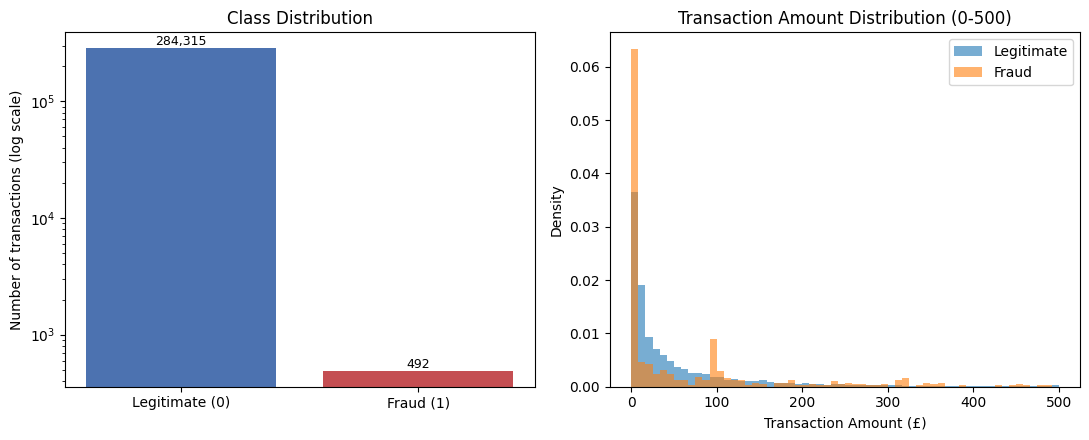

In [ ]:
counts = df["Class"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(["Legitimate (0)", "Fraud (1)"], counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_yscale("log")
axes[0].set_ylabel("Number of transactions (log scale)")
axes[0].set_title("Class Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

axes[1].hist(df[df.Class == 0]["Amount"], bins=60, alpha=0.6, label="Legitimate", density=True, range=(0, 500))
axes[1].hist(df[df.Class == 1]["Amount"], bins=60, alpha=0.6, label="Fraud", density=True, range=(0, 500))
axes[1].set_xlabel("Transaction Amount (£)")
axes[1].set_ylabel("Density")
axes[1].set_title("Transaction Amount Distribution (0-500)")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_eda.png", dpi=150)
plt.show()

## 6. Pipeline diagram  (Chapter 3.2, Figure 3.2)

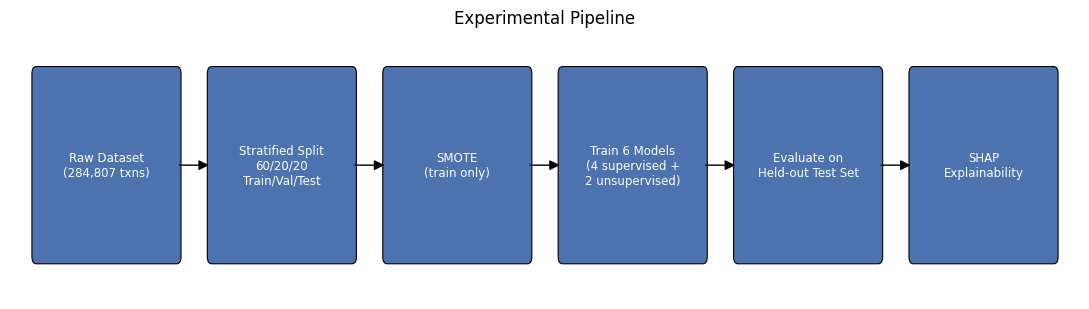

In [ ]:
steps = ["Raw Dataset\n(284,807 txns)", "Stratified Split\n60/20/20\nTrain/Val/Test",
         "SMOTE\n(train only)", "Train 6 Models\n(4 supervised +\n2 unsupervised)",
         "Evaluate on\nHeld-out Test Set", "SHAP\nExplainability"]

fig, ax = plt.subplots(figsize=(11, 3.2))

box_w, box_h = 1.6, 1.3
xs = [i * 2.0 for i in range(len(steps))]

for x, s in zip(xs, steps):
    rect = mpatches.FancyBboxPatch((x, 0), box_w, box_h, boxstyle="round,pad=0.05",
                                    facecolor="#4C72B0", edgecolor="black", linewidth=0.8)
    ax.add_patch(rect)
    ax.text(x + box_w/2, box_h/2, s, ha="center", va="center", fontsize=8.5, color="white")

for i in range(len(steps) - 1):
    arrow = FancyArrowPatch((xs[i]+box_w, box_h/2), (xs[i+1], box_h/2),
                             arrowstyle="-|>", mutation_scale=15, color="black")
    ax.add_patch(arrow)

ax.set_xlim(-0.3, xs[-1]+box_w+0.3)
ax.set_ylim(-0.3, box_h+0.3)
ax.axis("off")
ax.set_title("Experimental Pipeline", fontsize=12)
plt.tight_layout()
plt.savefig("fig_pipeline.png", dpi=150)
plt.show()

# 7. Train all six models

In [ ]:
scores = {}
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sm, y_train_sm)
scores["Logistic Regression"] = lr.predict_proba(X_test)[:, 1]
print(f"Logistic Regression: {time.time()-t0:.1f}s")

t0 = time.time()
rf = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
scores["Random Forest"] = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest: {time.time()-t0:.1f}s")

t0 = time.time()
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric="logloss",
                     random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")
xgb.fit(X_train_sm, y_train_sm)
scores["XGBoost"] = xgb.predict_proba(X_test)[:, 1]
print(f"XGBoost: {time.time()-t0:.1f}s")

t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=150, random_state=RANDOM_STATE,
                     early_stopping=True, n_iter_no_change=8)
mlp.fit(X_train_sm, y_train_sm)
scores["MLP"] = mlp.predict_proba(X_test)[:, 1]
print(f"MLP: {time.time()-t0:.1f}s")

t0 = time.time()
contamination = y_train.sum() / len(y_train)
iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train)  # unsupervised: no labels used
scores["Isolation Forest"] = -iso.score_samples(X_test)
print(f"Isolation Forest: {time.time()-t0:.1f}s")

t0 = time.time()
X_train_normal = X_train[y_train == 0]
ae = MLPRegressor(hidden_layer_sizes=(20, 8, 20), max_iter=200, random_state=RANDOM_STATE,
                   early_stopping=True, n_iter_no_change=8)
ae.fit(X_train_normal, X_train_normal)
recon = ae.predict(X_test)
recon_err = np.mean((X_test.values - recon) ** 2, axis=1)
scores["Autoencoder"] = recon_err
print(f"Autoencoder: {time.time()-t0:.1f}s")
print("All models trained.")

Logistic Regression: 11.1s
Random Forest: 461.8s
XGBoost: 20.5s
MLP: 26.6s
Isolation Forest: 5.0s
Autoencoder: 73.0s
All models trained.


## 8. Evaluate all models  (Chapter 3.4 / Chapter 4.1, Table 4.1)

In [ ]:
results = {}
for name, s in scores.items():
    auc = roc_auc_score(y_test, s)
    # F1-maximising threshold, not a fixed 0.5 cut-off.
    prec, rec, thr = precision_recall_curve(y_test, s)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = np.nanargmax(f1s[:-1])
    best_thr = thr[best_idx]
    preds = (s >= best_thr).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    cm = confusion_matrix(y_test, preds).tolist()
    results[name] = dict(precision=round(p,4), recall=round(r,4), f1=round(f1,4),
                          auc=round(auc,4), threshold=float(best_thr), cm=cm)

results_df = pd.DataFrame(results).T[["precision","recall","f1","auc"]]
results_df.columns = ["Precision","Recall","F1-Score","AUC-ROC"]
print(results_df.round(3))

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

                    Precision  Recall F1-Score AUC-ROC
Logistic Regression    0.8283  0.8367   0.8325   0.972
Random Forest          0.7879  0.7959   0.7919  0.9837
XGBoost                0.9398  0.7959   0.8619  0.9795
MLP                    0.8902  0.7449   0.8111  0.9657
Isolation Forest       0.3191  0.3061   0.3125  0.9533
Autoencoder            0.4834  0.7449   0.5863  0.9444


## 9. ROC curves, PR curves, confusion matrices  (Chapter 4.1, Figures 4.1–4.3)

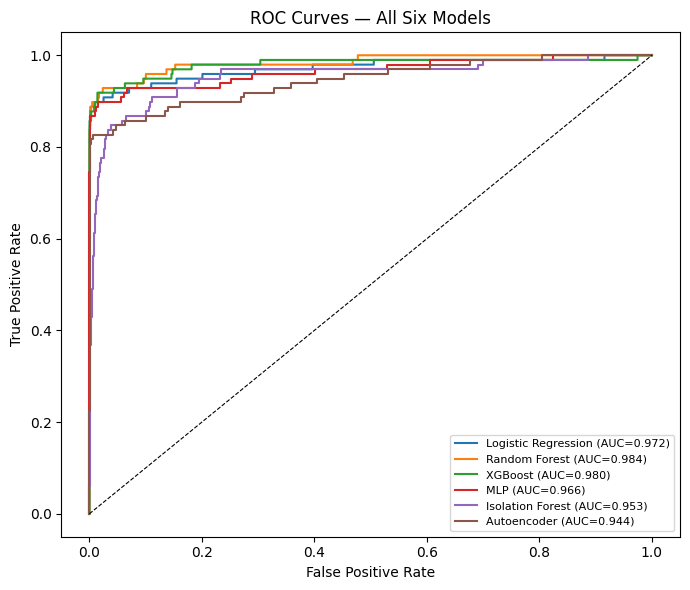

In [ ]:
# ROC curves
plt.figure(figsize=(7,6))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})")
plt.plot([0,1],[0,1],"k--", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Six Models")
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig("fig_roc.png", dpi=150)
plt.show()

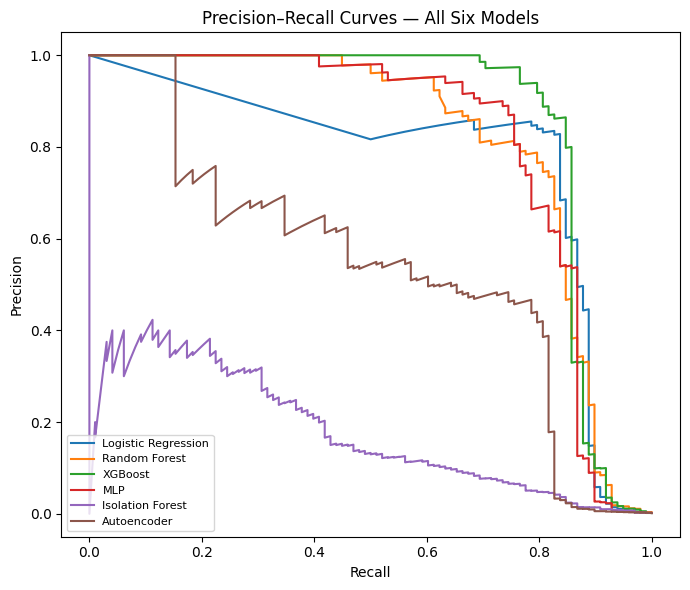

In [ ]:
# Precision-Recall curves
plt.figure(figsize=(7,6))
for name, s in scores.items():
    prec, rec, _ = precision_recall_curve(y_test, s)
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curves — All Six Models")
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig("fig_pr.png", dpi=150)
plt.show()

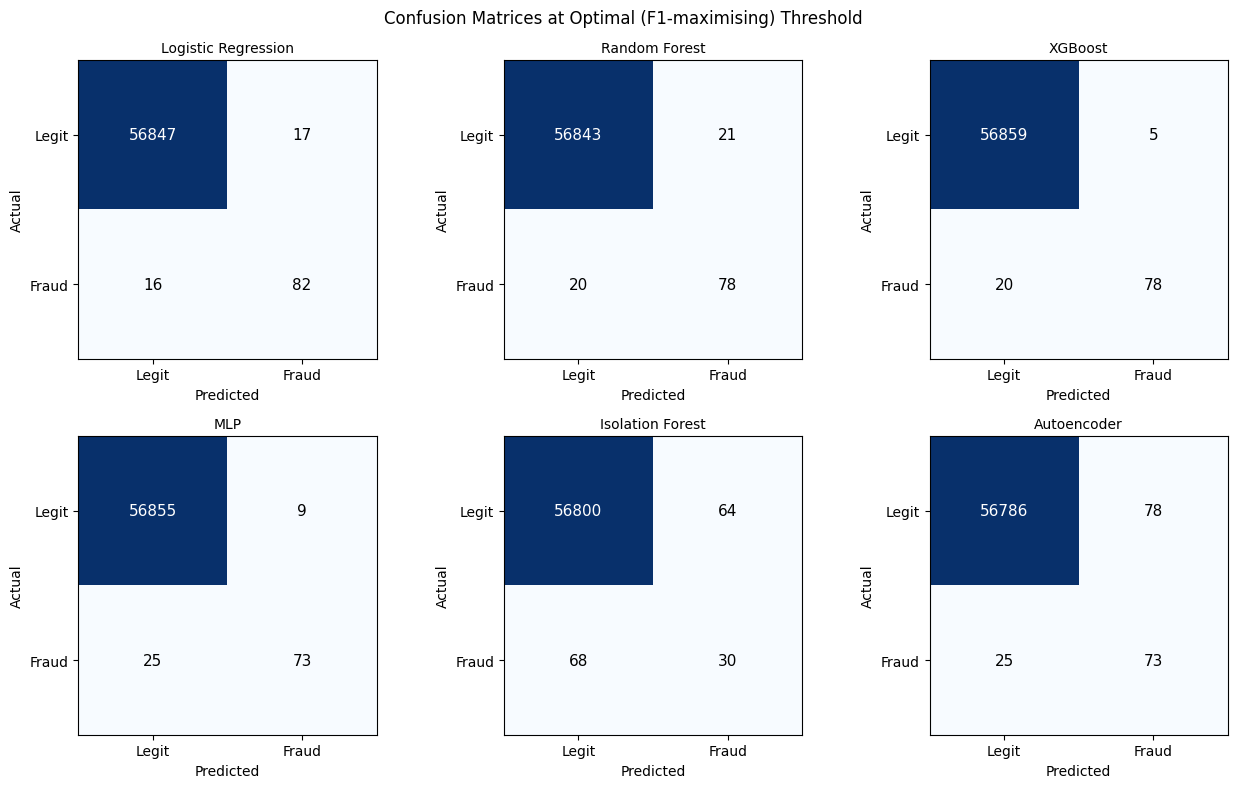

In [ ]:
# Confusion matrices grid
fig, axes = plt.subplots(2,3, figsize=(13,8))
for ax, name in zip(axes.flat, scores.keys()):
    cm = np.array(results[name]["cm"])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Legit","Fraud"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["Legit","Fraud"])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j], ha="center", va="center",
                     color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices at Optimal (F1-maximising) Threshold", fontsize=12)
plt.tight_layout()
plt.savefig("fig_cm.png", dpi=150)
plt.show()

## 10. SHAP explainability for best model (XGBoost)  (Chapter 4.1, Figure 4.4)

/tmp/ipykernel_822/1003017290.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample, show=False, max_display=12)


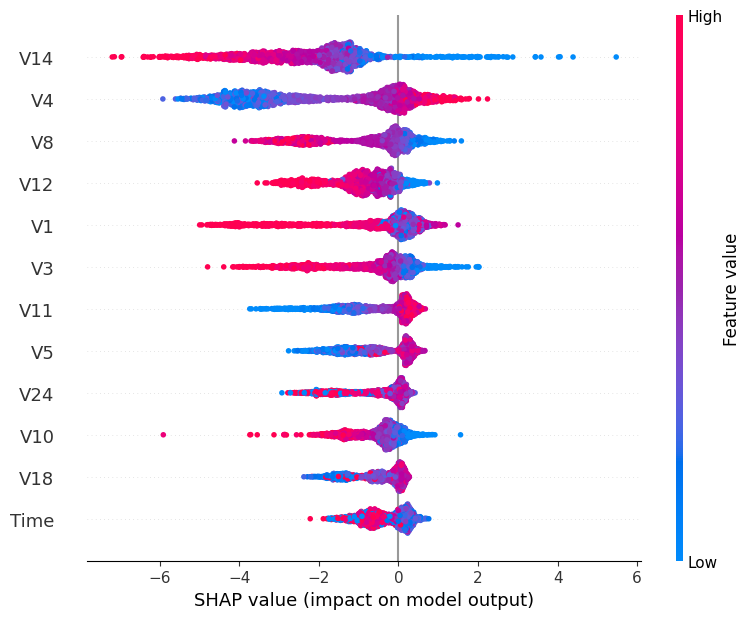

In [ ]:
sample = X_test.sample(n=2000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample)
plt.figure()
shap.summary_plot(shap_values, sample, show=False, max_display=12)
plt.tight_layout()
plt.savefig("fig_shap.png", dpi=150, bbox_inches="tight")
plt.show()